# Customer Intelligence & Churn Prediction Platform

## Phase 5: Exploratory Data Analysis (EDA)

**Objective**

Explore the cleaned and engineered datasets to understand customer behavior, sales performance, product trends, payment patterns, delivery performance, and business insights through descriptive statistics and visualizations.

**Dataset**

Olist Brazilian E-Commerce Public Dataset (Processed)

**Author**

Tanish Mhatre

---

## Notebook Roadmap

**1. Load Processed Datasets**
- Load cleaned datasets for analysis.

**2. Dataset Overview**
- Verify dataset structure, dimensions, and basic information.

**3. Order Analysis**
- Analyze order status, order volume, and purchase trends.

**4. Sales Analysis**
- Explore sales distribution, revenue trends, and customer spending.

**5. Customer Analysis**
- Analyze customer purchase behavior, frequency, recency, and spending.

**6. Product Analysis**
- Explore product categories, product distribution, and sales performance.

**7. Payment Analysis**
- Analyze payment methods, installments, and payment values.

**8. Delivery Analysis**
- Examine delivery times, delays, and logistics performance.

**9. Review Analysis**
- Analyze customer ratings and review score distribution.

**10. Business Insights**
- Summarize key findings and actionable business recommendations.

---

## Import Libraries

Import the required libraries for data manipulation, visualization, and analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
## Load Processed Datasets
#Load the cleaned datasets created during the data preprocessing phase.

customers = pd.read_csv("../data/processed/customers_clean.csv")
orders = pd.read_csv("../data/processed/orders_clean.csv")
order_items = pd.read_csv("../data/processed/order_items_clean.csv")
payments = pd.read_csv("../data/processed/payments_clean.csv")
reviews = pd.read_csv("../data/processed/reviews_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")
sellers = pd.read_csv("../data/processed/sellers_clean.csv")

## Store Datasets

Store all datasets in a dictionary for quick access and validation.

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers
}

### Verify Dataset Shapes

Check whether all processed datasets have been loaded successfully.

In [5]:
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)


### Order Status Analysis

Analyze the distribution of order statuses to understand order fulfillment performance.

In [6]:
# Count the number of orders for each status

order_status_counts = (
    orders["order_status"]
    .value_counts()
)

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [ ]:
# Calculate the percentage distribution of each order status

order_status_percentage = (
    orders["order_status"].value_counts(normalize=True)
    .mul(100)
    .round(2)
)   

order_status_percentage

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

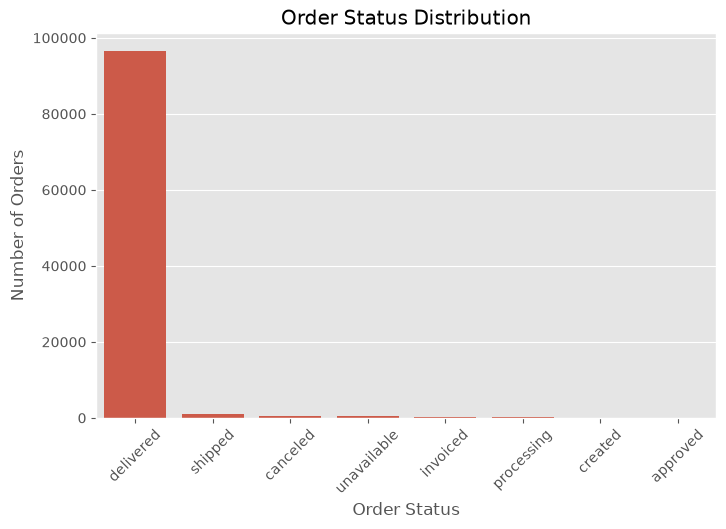

In [8]:
# Create a bar chart showing the distribution of order statuses

plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)

# Add chart title and axis labels

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

# Rotate x-axis labels for better readability

plt.xticks(rotation=45)

# Display the chart

plt.show()

## Monthly Order Trend Analysis

Analyze how the number of orders changes over time to identify business growth and seasonal trends.

In [ ]:
# Convert purchase timestamp to datetime

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

# Create a new column containing only the year and month

orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

# Count the number of orders placed in each month

monthly_orders = (
    orders
    .groupby("purchase_month")
    .size()
    .reset_index(name="total_orders")
)

# Display the first few rows

monthly_orders.head()

,purchase_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


In [12]:
# Convert Period to Timestamp for plotting

monthly_orders["purchase_month"] = (
    monthly_orders["purchase_month"]
    .dt.to_timestamp()
)

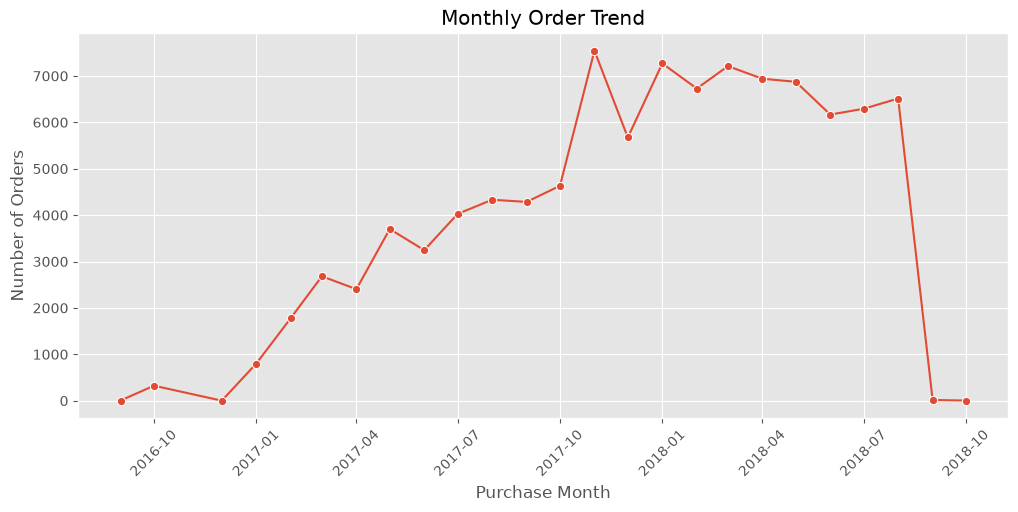

In [13]:
# Create a line chart showing monthly order trends

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="purchase_month",
    y="total_orders",
    marker="o"
)

# Add chart title and labels

plt.title("Monthly Order Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")

# Rotate x-axis labels

plt.xticks(rotation=45)

# Display the chart

plt.show()

## Monthly Sales Revenue Analysis

Analyze monthly sales revenue to identify business growth, seasonal trends, and revenue performance over time.

In [14]:
# Merge orders with order items to obtain purchase date and item value

sales_data = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

# Calculate the total value of each item

sales_data["item_value"] = (
    sales_data["price"] +
    sales_data["freight_value"]
)

# Convert purchase timestamp to datetime

sales_data["order_purchase_timestamp"] = pd.to_datetime(
    sales_data["order_purchase_timestamp"]
)

# Extract purchase month

sales_data["purchase_month"] = (
    sales_data["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [15]:
# Calculate total revenue for each month

monthly_sales = (
    sales_data
    .groupby("purchase_month")["item_value"]
    .sum()
    .reset_index(name="total_revenue")
)

# Convert Period to Timestamp for plotting

monthly_sales["purchase_month"] = (
    monthly_sales["purchase_month"]
    .dt.to_timestamp()
)

# Display first few rows

monthly_sales.head()

,purchase_month,total_revenue
0,2016-09-01,354.75
1,2016-10-01,56808.84
2,2016-12-01,19.62
3,2017-01-01,137188.49
4,2017-02-01,286280.62


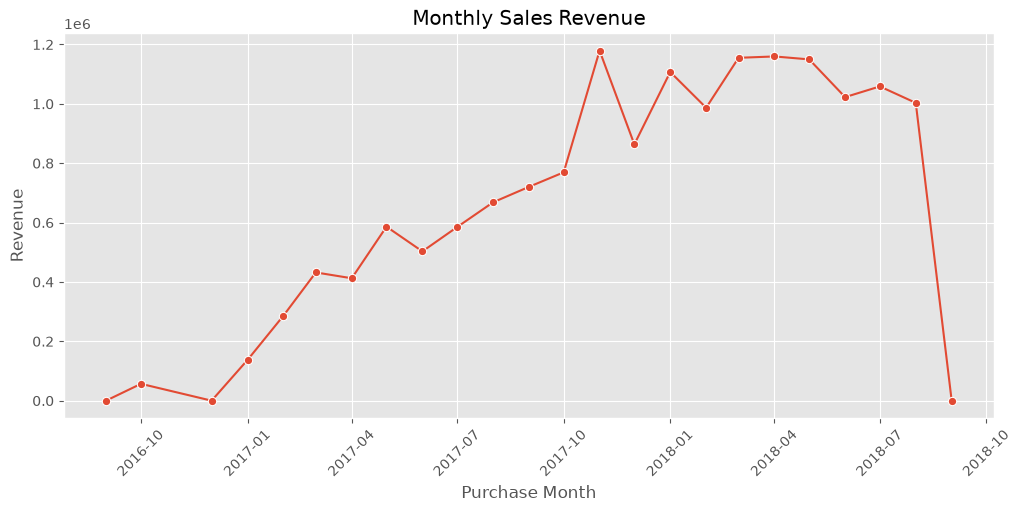

In [16]:
# Create a line chart showing monthly revenue

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="purchase_month",
    y="total_revenue",
    marker="o"
)

# Add title and labels

plt.title("Monthly Sales Revenue")
plt.xlabel("Purchase Month")
plt.ylabel("Revenue")

# Rotate x-axis labels

plt.xticks(rotation=45)

# Display the chart

plt.show()

## Revenue Distribution Analysis

Analyze the distribution of order values to understand customer spending patterns and identify high-value orders.

## Create Analysis Tables

Create derived tables required for exploratory data analysis.


In [19]:
# Create total value for each order item

order_items["item_value"] = (
    order_items["price"] +
    order_items["freight_value"]
)

# Calculate total order value

order_value = (
    order_items
    .groupby("order_id")["item_value"]
    .sum()
    .reset_index(name="order_value")
)

# Display first few rows

order_value.head()

,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [20]:
sales_data = orders.merge(
    order_value,
    on="order_id",
    how="left"
)

In [21]:
# Merge orders with order values

sales_data = orders.merge(
    order_value,
    on="order_id",
    how="left"
)

# Display first few rows

sales_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,28.62


In [22]:
# Display summary statistics of order value

sales_data["order_value"].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: order_value, dtype: float64

In [23]:
# Display the top 10 highest-value orders

sales_data.sort_values(
    "order_value",
    ascending=False
).head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,order_value
13390,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,2017-09,13664.08
66599,736e1922ae60d0d6a89247b851902527,ec5b2ba62e574342386871631fafd3fc,delivered,2018-07-15 14:49:44,2018-07-17 04:31:36,2018-07-20 13:09:00,2018-07-26 22:03:06,2018-08-02,2018-07,7274.88
22171,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,delivered,2017-02-12 20:37:36,2017-02-12 20:45:12,2017-02-16 09:23:13,2017-03-03 14:23:18,2017-03-09,2017-02,6929.31
28326,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,delivered,2018-07-25 18:10:17,2018-07-27 04:05:13,2018-08-03 14:42:00,2018-08-15 14:57:50,2018-08-10,2018-07,6922.21
3508,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,delivered,2017-05-24 18:14:34,2017-05-26 02:45:17,2017-05-26 11:20:47,2017-06-05 17:09:48,2017-06-28,2017-05,6726.66
32322,2cc9089445046817a7539d90805e6e5a,05455dfa7cd02f13d132aa7a6a9729c6,delivered,2017-11-24 11:03:35,2017-11-28 12:55:46,2017-12-06 11:52:14,2017-12-13 12:16:02,2017-12-22,2017-11,6081.54
53352,a96610ab360d42a2e5335a3998b4718a,df55c14d1476a9a3467f131269c2477f,delivered,2017-04-01 15:58:40,2017-04-03 13:25:18,2017-04-11 15:10:34,2017-04-17 11:04:45,2017-05-02,2017-04,4950.34
41086,b4c4b76c642808cbe472a32b86cddc95,e0a2412720e9ea4f26c1ac985f6a7358,canceled,2018-07-12 12:08:36,2018-07-12 12:25:53,NaN,NaN,2018-08-01,2018-07,4809.44
40327,199af31afc78c699f0dbf71fb178d4d4,24bbf5fd2f2e1b359ee7de94defc4a15,delivered,2017-04-18 18:50:13,2017-04-19 15:50:15,2017-04-25 13:39:59,2017-05-07 10:42:39,2017-05-15,2017-04,4764.34
40342,8dbc85d1447242f3b127dda390d56e19,3d979689f636322c62418b6346b1c6d2,delivered,2018-06-22 12:23:19,2018-06-22 12:36:36,2018-06-22 13:00:00,2018-07-06 01:08:30,2018-07-17,2018-06,4681.78


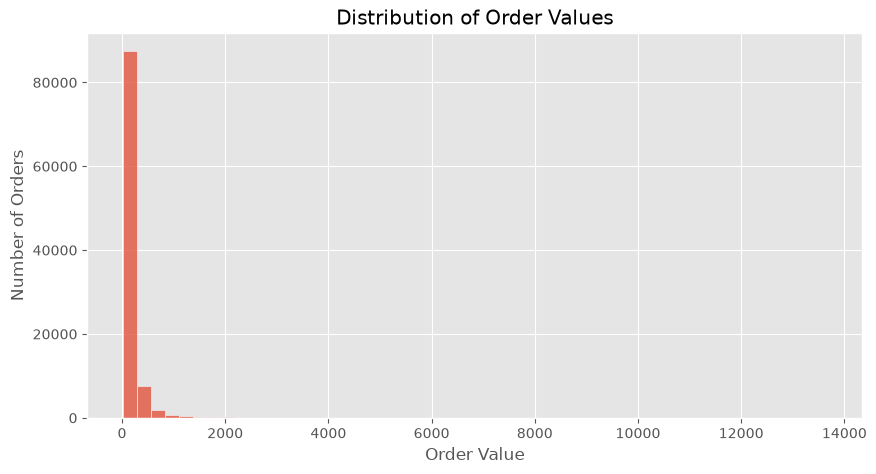

In [24]:
# Create a histogram showing the distribution of order values

plt.figure(figsize=(10, 5))

sns.histplot(
    data=sales_data,
    x="order_value",
    bins=50
)

# Add chart title and axis labels

plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

# Display the chart

plt.show()

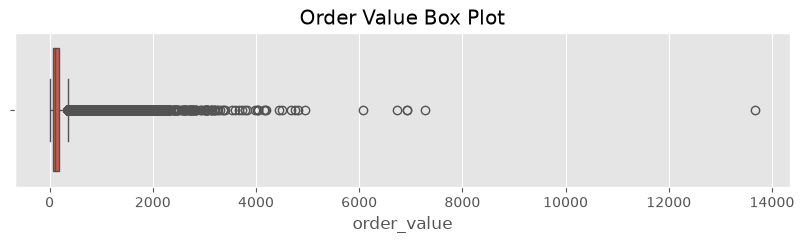

In [25]:
# Create a box plot to identify outliers

plt.figure(figsize=(10, 2))

sns.boxplot(
    x=sales_data["order_value"]
)

# Add chart title

plt.title("Order Value Box Plot")

# Display the chart

plt.show()

## Customer Spending Distribution

Analyze the total spending of customers to understand spending behavior and identify high-value customers.

In [27]:
customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

customer_features.head()

,customer_unique_id,total_orders,total_spent,average_order_value,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,163
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,585
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,369
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,336
